# **NESTL Toolkit Assistant RAG with Hybrid Retrieval**
Objective:
The goal of this notebook is to build a simple Retrieval-Augmented Generation (RAG) pipeline over an Education and Training document.

### Problem Statement

The NESTL (Neurodivergent Education for Students, Teaching & Learning) project aims to support neurodivergence-inclusive learning and teaching in higher education, co-created by Staff and Students in the University of Oxford.

We want to make this framework accessible to teachers in underserved communities and non-urban school systems in India to develop and practice neurodiversity and increase awareness and sensitivity. This training requires continuous practice and adoption. To support this, we built a **RAG-based Teaching Assistant** that retrieves Cases, Literature, and resources to generate accurate responses guided by policies, using OpenAI API and hybrid retrieval.


## High-Level Steps (Roadmap)

1. Setting up the Environment  
2. Loading the NESTL Toolkit PDF  
3. Splitting the Document into Chunks  
4. Creating Embeddings  
5. Building the Vector Database  
6. Creating BM25 Retrieval  
7. Combining Dense + BM25 into Hybrid Retrieval  
8. Building the RAG Chain  
9. Testing the Teaching Assistant  
10. Running Basic RAG Evaluation

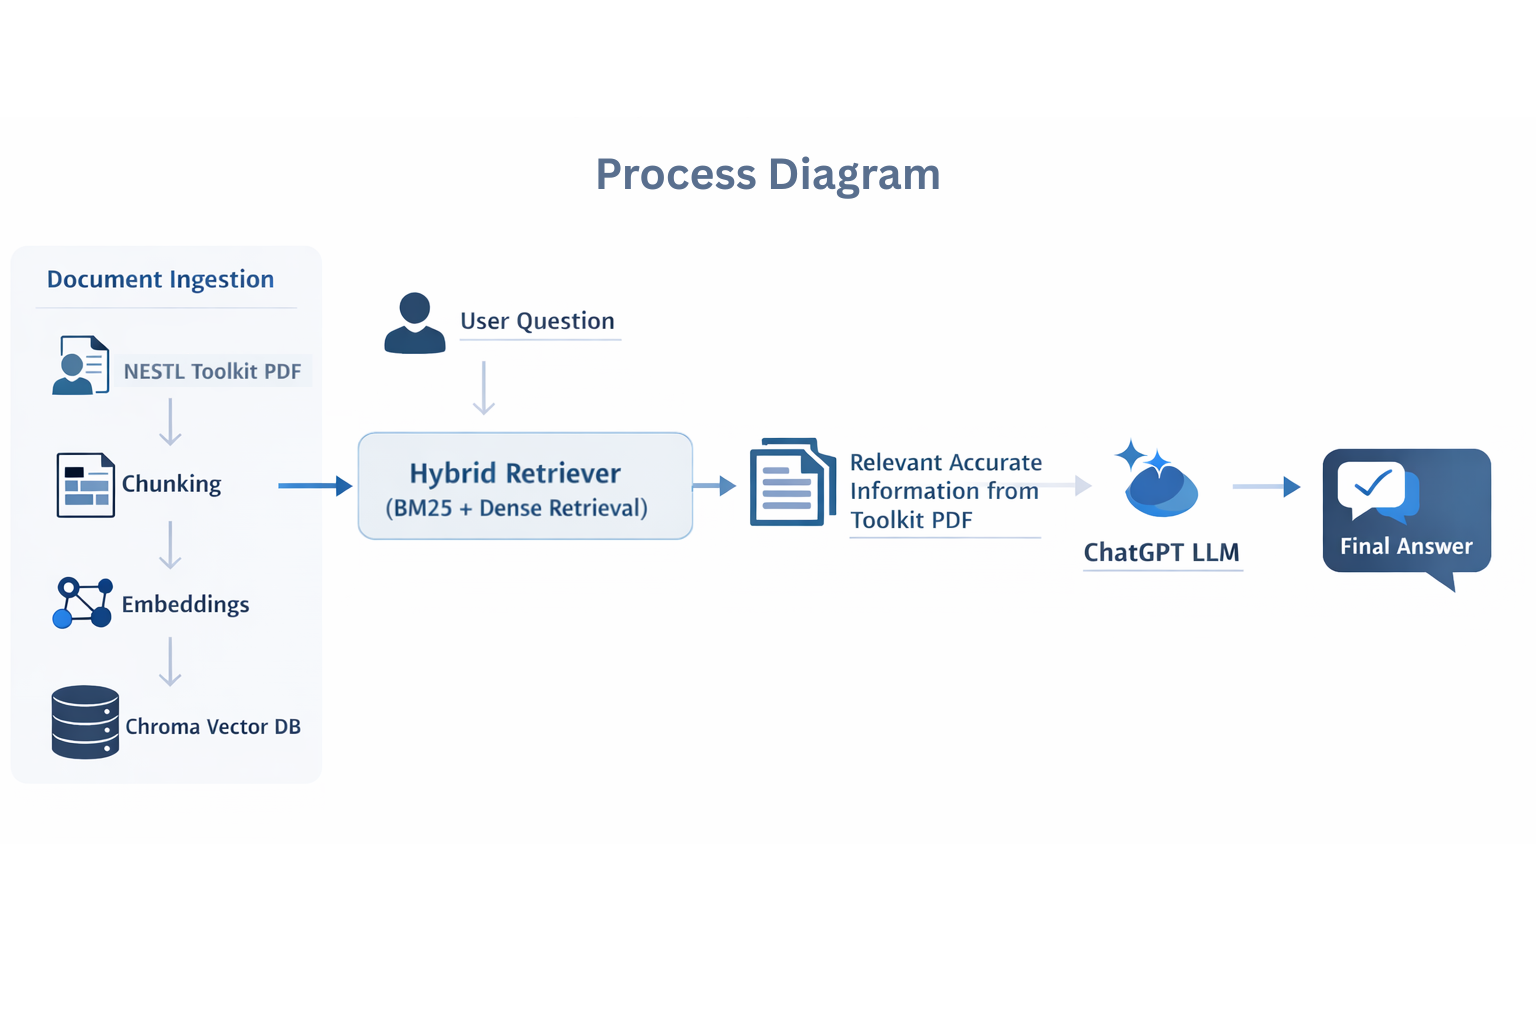

## Step 1: Setting up the Environment

In this step, we install the required libraries and configure access to OpenAI.


In [49]:
!pip -q install -U \
  langchain \
  langchain-core \
  langchain-classic \
  langchain-community \
  langchain-text-splitters \
  langchain-openai \
  langchain-chroma \
  chromadb \
  pypdf \
  rank_bm25 \
  deepeval

Set the OpenAI API key in the environment so both the embedding model and the chat model can authenticate without hardcoding credentials in the notebook.

In [50]:
import os, getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key:")

## Step 2: Loading the NESTLE Toolkit PDF

In this step, we load the toolkit document into LangChain.

The PDF is read page by page so that each page becomes a document object.  
This makes it easier to track source pages later during retrieval and answer generation.

In [51]:
from google.colab import files

uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

print("Uploaded file:", pdf_path)

Saving NESTL-Toolkit-Main.pdf to NESTL-Toolkit-Main (2).pdf
Uploaded file: NESTL-Toolkit-Main (2).pdf


Now we load the PDF using `PyPDFLoader`, which reads the document page by page and converts each page into a LangChain `Document` object.

We also enrich each document's metadata with an explicit `page` number and `source` path. This metadata travels with every chunk through the entire pipeline and is later used to cite which pages the final answer was drawn from.

In [52]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(pdf_path)
docs = loader.load()

for i, doc in enumerate(docs):
    doc.metadata["page"] = i + 1
    doc.metadata["source"] = pdf_path

print("Total pages:", len(docs))
print(docs[0].page_content[:152])

Total pages: 152
Page 1 of 152 
 
       
Neurodivergent  Education for  Students,  Teaching &  Learning (NESTL)  Toolkit


## Step 3: Splitting the Document into Chunks

Toolkits PDFs usually contain long paragraphs, instructions and multiple sections on the same page.  
To improve retrieval quality, we split the document into smaller overlapping chunks.

This helps:
- semantic search work better
- keyword search become more precise
- the model answer from more focused case scenarios text

In [53]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100
)

chunks = splitter.split_documents(docs)

print("Total chunks:", len(chunks))
print(chunks[0].metadata)
print(chunks[0].page_content[:152])

Total chunks: 471
{'producer': 'macOS Version 12.7.5 (Build 21H1222) Quartz PDFContext', 'creator': 'PyPDF', 'creationdate': "D:20250612095156Z00'00'", 'moddate': "D:20250612095156Z00'00'", 'source': 'NESTL-Toolkit-Main (2).pdf', 'total_pages': 152, 'page': 1, 'page_label': '1'}
Page 1 of 152 
 
       
Neurodivergent  Education for  Students,  Teaching &  Learning (NESTL)  Toolkit


## Step 4: Creating Embeddings

In this step, we convert each policy chunk into a vector representation using **OpenAI embeddings**.

Embeddings make it possible to retrieve text by meaning, not just exact word match.
This is useful when teachers ask questions in natural language that may not exactly match toolkit wording.

In [54]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

## Step 5: Building the Vector Database

 We store them in **ChromaDB**.

Chroma acts as our dense retriever backend:
- it stores chunk embeddings
- performs similarity search
- returns the most semantically relevant chunks for a query

In [55]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="NESTL_toolkit_rag"
)

dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

## Step 6: Creating BM25 Retrieval

Dense retrieval is strong at meaning-based search, but documents also benefit a lot from exact keyword matching.

To improve retrieval quality, we add a **BM25 retriever**.
BM25 is especially useful for:
- policy names
- official terms
- exact phrases
- specific procedural wording

This becomes the keyword-search part of our hybrid retrieval setup.

In [56]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 4

## Step 7: Combining Dense + BM25 into Hybrid Retrieval

Now we combine:
- **Dense retrieval** from ChromaDB
- **BM25 retrieval** for keyword matching

This hybrid approach gives better results than using either method alone.

Why hybrid retrieval works well for this document:
- BM25 helps with exact section names and compliance wording
- Dense search helps with paraphrased teachers' questions

In [57]:
from langchain_classic.retrievers import EnsembleRetriever

hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.5, 0.5]
)

In [58]:
query = "How can I make a neurodivergent student feel more comfortable in my classroom environment?"

docs_found = hybrid_retriever.invoke(query)

for i, d in enumerate(docs_found[:3], 1):
    print(f"\n--- Result {i} | Page {d.metadata.get('page')} ---")
    print(d.page_content[:500])


--- Result 1 | Page 50 ---
students you interact with so that the emotional labour is divided more evenly. This can create a more nurturing, inclusive teaching environment that benefits all students and staff.  Neurodivergent Staff’s Experiences and Opinions  One staff member, whilst explaining the various effective strategies they had developed for doing their research and teaching in their own neurodivergent way, commented: “The biggest difference comes from permission. After the diagnosis, I permit myself to be differe

--- Result 2 | Page 100 ---
📖 Case Study 1: Syllabus Accessibility Statement | Dr Laura Seymour  Senior Lecturer in English, Swansea University  The following statement is provided by Dr Seymour, also shared in the earlier section. Please feel free to adapt and develop your own syllabus accessibility statement.  ‘Ensuring accessibility for disabled and neurodivergent students, whether or not they have a diagnosis, is an essential part of my job. I have taken the fol

## Step 8: Building the RAG Chain

In this step, we connect retrieval with the OpenAI LLM.

The RAG chain works like this:
1. Accept a user question
2. Retrieve the most relevant answer chunks
3. Format them into context
4. Ask OpenAI to answer only from that context
5. Return a grounded response

In [59]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

We also use a strict prompt so the model:
- answers only from retrieved toolkit text
- avoids hallucinating
- clearly says when the answer is not found in the document

In [60]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
You are a teaching and learning assistant.

Answer only from the provided toolkit context.
If the answer is not available, say: "Not found in the toolkit document."

Give a short, clear answer.
At the end, mention the source page numbers used.

Context:
{context}

Question:
{question}
""")

In [61]:
def format_docs_with_sources(docs):
    formatted = []
    for d in docs:
        page = d.metadata.get("page", "N/A")
        text = d.page_content.strip()
        formatted.append(f"[Page {page}]\n{text}")
    return "\n\n".join(formatted)

In [62]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

rag_chain = (
    {
        "context": hybrid_retriever | format_docs_with_sources,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [63]:
question = "How can I make a neurodivergent student feel more comfortable in my classroom environment?"
answer = rag_chain.invoke(question)

print("Question:", question)
print("Answer:", answer)

Question: How can I make a neurodivergent student feel more comfortable in my classroom environment?
Answer: To make a neurodivergent student feel more comfortable, start from a position of strength and positivity, create a safe and inclusive environment where students feel comfortable sharing their accessibility needs, and indicate at the start of the course that you are available to discuss specific concerns and can adjust teaching accordingly. Also, openly signal your support without singling them out. (Pages 44, 83, 94)


## Step 9: Testing the Teaching Assistant

Now we test the assistant with real scenario questions from the toolkit document.

Examples include:
- communication rules
- documenting process
- academic policies
- grievance resolution timelines
- disciplinary actions

In [64]:
questions = [
    "What is the school's policy on documentation for the protection of students' safety?",
    "Why is neurodivergence-inclusive teaching and learning important?",
    "What do ‘neurodivergence’ and ‘neurodiversity’ mean?",
    "Why is it important to discuss issues around diagnoses?",
    "What are the Four Forces of Change?"
]

for q in questions:
    print("\nQ:", q)
    print("A:", rag_chain.invoke(q))


Q: What is the school's policy on documentation for the protection of students' safety?
A: The school treats information shared by students as strictly confidential but will break confidentiality if there is a risk of them harming themselves or others, in which case the student should also be informed. 

Source: Page 45

Q: Why is neurodivergence-inclusive teaching and learning important?
A: Neurodivergence-inclusive teaching is important because it enables neurodivergent students to achieve their full potential in a safe environment, nurtures more inclusive, ethical, equal, and diverse learning environments, ensures respect for each student's unique perspectives, empowers all students to thrive academically and personally, and enhances institutional cultures that value diversity and individuality. 

(Source: Page 12)

Q: What do ‘neurodivergence’ and ‘neurodiversity’ mean?
A: Neurodiversity describes the natural variation in the ways that people think, sense, feel, and behave. Neurod

## Step 10: Running Basic RAG Evaluation

In this step, we do a simple evaluation of our RAG pipeline.

The goal is to test whether:
- the retrieved context is relevant
- the answer is grounded in that context
- the final response matches the expected policy content

In [65]:
question = "What are some specific diverse assessment approaches?"

retrieved_docs = hybrid_retriever.invoke(question)

print("QUESTION:", question)
print("\nRETRIEVED CHUNKS:")

for i, d in enumerate(retrieved_docs[:3], 1):
    print(f"\n--- Chunk {i} | Page {d.metadata.get('page')} ---")
    print(d.page_content[:600])

print("\nFINAL ANSWER:")
print(rag_chain.invoke(question))

QUESTION: What are some specific diverse assessment approaches?

RETRIEVED CHUNKS:

--- Chunk 1 | Page 79 ---
educators can advocate for a diversification of assessment methods and plurality of modes when designing and modifying courses.

--- Chunk 2 | Page 80 ---
level, experiment with creative methods, and help guide the student to craft a traditional academic essay eventually. Unpolished work is generally best for meaningful formative work – it allows you to work alongside the student to support them in their writing practice using diverse formats.  • Check your biases when it comes to assessment – even seemingly neutral language in assessment criteria can be ableist. For example, some assessment criteria ask students to write a ‘well-organised’ essay with a single through-line of argument. This can exclude students with ADHD or dyslexia whose minds 

--- Chunk 3 | Page 49 ---
Neurodivergent Staff’s Experiences and Opinions  One staff member we interviewed suggested reading memoirs 

## Step 11: Evaluate the RAG Pipeline with Deepeval

In this step, we use the `deepeval` framework to evaluate the performance of our RAG pipeline. We'll define specific metrics to assess the quality of the generated answers and the retrieved context.

We will evaluate the following aspects:
- **Faithfulness**: How well the answer is grounded in the retrieved context.
- **Answer Relevancy**: How relevant the answer is to the user's question.
- **Contextual Relevancy**: How relevant the retrieved context is to the user's question.

In [66]:
from deepeval.metrics import FaithfulnessMetric, AnswerRelevancyMetric, ContextualRelevancyMetric
from deepeval import evaluate
from deepeval.test_case import LLMTestCase

Now, let's define the metrics we'll use for evaluation.

In [67]:
# Define the evaluation metrics
faithfulness_metric = FaithfulnessMetric(threshold=0.7, model='gpt-4.1-mini')
answer_relevancy_metric = AnswerRelevancyMetric(threshold=0.7, model='gpt-4.1-mini')
contextual_relevancy_metric = ContextualRelevancyMetric(threshold=0.7, model='gpt-4.1-mini')

Next, we will define a few test cases. Each test case includes a question, an expected answer, and a set of retrieved documents. The `rag_chain` will generate the actual answer based on the question and retrieved context.

In [68]:
test_cases = [
    LLMTestCase(
        input="Who is the NESTL toolkit designed for?",
        actual_output=rag_chain.invoke("Who is the NESTL toolkit designed for?"),
        retrieval_context=[d.page_content for d in hybrid_retriever.invoke("Who is the NESTL toolkit designed for?")],
        expected_output="The NESTL toolkit is mainly designed for staff with teaching responsibilities in higher education and neurodivergent students. It may also be useful for administrators, course conveners, and library staff supporting teaching and learning. :contentReference[oaicite:0]{index=0}"
    ),
    LLMTestCase(
        input="What are the four areas of action in the NESTL framework?",
        actual_output=rag_chain.invoke("What are the four areas of action in the NESTL framework?"),
        retrieval_context=[d.page_content for d in hybrid_retriever.invoke("What are the four areas of action in the NESTL framework?")],
        expected_output="The NESTL framework outlines four areas of action: Awareness and Understanding, Teaching Practice, Space and Materials, Assessment and Feedback, and Adjustment and Support. These areas guide inclusive teaching and learning practices. :contentReference[oaicite:1]{index=1}"
    ),
    LLMTestCase(
        input="How can teachers start using the NESTL toolkit in their practice?",
        actual_output=rag_chain.invoke("How can teachers start using the NESTL toolkit in their practice?"),
        retrieval_context=[d.page_content for d in hybrid_retriever.invoke("How can teachers start using the NESTL toolkit in their practice?")],
        expected_output="Teachers can start using the NESTL toolkit by engaging with it at their own pace, reflecting on their teaching practices, and implementing even one small change to support neurodivergence-inclusive learning. The toolkit encourages gradual adoption and practical application in classroom contexts. :contentReference[oaicite:2]{index=2}"
    )
]


In [69]:
# Run the evaluation
evaluate(
    test_cases=test_cases,
    metrics=[
        faithfulness_metric,
        answer_relevancy_metric,
        contextual_relevancy_metric
    ],
    hyperparameters={
        "prompt": prompt.messages[0].prompt.template
    }
)

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4.1-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4.1-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4.1-mini, strict=False, 
async_mode=True)...

Output()

INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases




Metrics Summary

  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4.1-mini, reason: The score is 1.00 because there are no contradictions; the actual output fully aligns with the retrieval context. Great job maintaining accuracy!, error: None)
  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4.1-mini, reason: The score is 1.00 because the response fully addresses the question without any irrelevant information, providing a clear and focused answer about the four areas of action in the NESTL framework. There are no extraneous statements that would lower the relevancy., error: None)
  - ❌ Contextual Relevancy (score: 0.6666666666666666, threshold: 0.7, strict: False, evaluation model: gpt-4.1-mini, reason: The score is 0.67 because while the retrieval context includes relevant statements such as 'At the core of the framework are the four areas of action' and lists them explicitly, much of the context focuses on

⚠ WARNING: No prompts logged.
» ]8;id=347765;https://deepeval.com/docs/evaluation-prompts\Log prompts]8;;\ to evaluate and optimize your prompt templates and models.

================================================================================

✓ Evaluation completed 🎉! (time taken: 8.75s | token cost: 0.0187844 USD)
» Test Results (3 total tests):
   » Pass Rate: 0.0% | Passed: 0 | Failed: 3

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

EvaluationResult(test_results=[TestResult(name='test_case_1', success=False, metrics_data=[MetricData(name='Faithfulness', threshold=0.7, success=True, score=1.0, reason='The score is 1.00 because there are no contradictions; the actual output fully aligns with the retrieval context. Great job maintaining accuracy!', strict_mode=False, evaluation_model='gpt-4.1-mini', error=None, evaluation_cost=0.0016196000000000001, verbose_logs='Truths (limit=None):\n[\n    "There are four forces of change that drive areas of transformation: Individual, Communal, Institutional, and Sectoral.",\n    "A Framework for Neurodivergent-Inclusive Teaching and Learning was developed from the NESTL project.",\n    "The framework centers on four areas of action vital to fostering neurodivergent-inclusive teaching and learning: Awareness and Understanding; Teaching Practice, Space, and Materials; Assessment and Feedback; Adjustment and Support.",\n    "Each area of action requires four forces of change to driv

## Conclusion

In this notebook, we built a simple **Teaching Assistant RAG system** using:

- OpenAI for chat and embeddings
- ChromaDB for dense retrieval
- BM25 for keyword retrieval
- Hybrid retrieval for better policy search

This workflow is a strong starting point for building internal assistants that answer teaching/staff's questions from training documents in a grounded and scalable way.